In [1]:
# построение фрактала Папоротник
# с помощью алгоритма ДСИФ

# Ячейка № 1

# подключение библиотеки
import numpy as np

# подключение библиотеки matplotlib.pyplot
import matplotlib.pyplot as plt


In [2]:
# Ячейка № 2

# задание функции, возвращающей
# правила итераций фрактала Папоротник
def Rule_Paporotnic(Digit):
    Tmp_list = []

    for i in range(4**Digit):
        Str_Digit = ""
        Number = i

        while Number > 0:
            Str_Digit = str(Number % 4) + Str_Digit
            Number = Number // 4
        if i == 0:
            Tmp_list.append("0")
        else:
            Tmp_list.append(Str_Digit)

    return Tmp_list


In [3]:
# Ячейка № 3

# задание функции, возвращающей
# изображение фрактала Папоротник
def Draw_Paporotnic(N_Iter, N_Points, x, y, A1, A2, A3, A4, a1, a2, a3, a4, Cod_list):
    # входные переменные:
    # N_Iter - число итераций
    # N_Points - число базовых точек
    # A1, A2, A3, A4, a1, a2, a3, a4 -- параметры
    #                                   аффинных преобразований

    # вычисление координат фрактала Папоротник
    for m in range(4**N_Iter):
        X = x[:]
        Y = y[:]
        Rule_Step_list = Cod_list[m]

        for i in range(N_Iter):
            Tmp = Rule_Step_list[N_Iter - 1 - i]
            if Tmp == "0":
                [X, Y] = Affin_Transform(N_Points, X, Y, A1, a1)
            if Tmp == "1":
                [X, Y] = Affin_Transform(N_Points, X, Y, A2, a2)
            if Tmp == "2":
                [X, Y] = Affin_Transform(N_Points, X, Y, A3, a3)
            if Tmp == "3":
                [X, Y] = Affin_Transform(N_Points, X, Y, A4, a4)

        # отображение точек фрактала Папоротник
        plt.plot(X, Y, ".k", markersize=0.1)


In [ ]:
# Ячейка № 4

# задание функции, формирующей
# изображение фрактала Папоротник
def Paporotnic_DSIF(N_Iter, N_Points):
    # входные переменные:
    # N_Iter - порядок ковра
    # N_Points - число испытаний
    #           метода Монте-Карло

    # задание координат базового треугольника

    # инициализация генератора случайных чисел
    np.random.seed()

    # инициализация массивов, используемых
    # для хранения координат точек фрактала Папоротник
    x = np.zeros(N_Points)
    y = np.zeros(N_Points)

    # задание значений начальных
    # координат базовых точек
    j = 1
    while j <= N_Points:
        Tmp_X = np.random.uniform(0, 1)
        Tmp_Y = np.sqrt(3) / 2 * np.random.uniform(0, 1)
        if (
            -np.sqrt(3) * Tmp_X + Tmp_Y <= 0
            and np.sqrt(3) * Tmp_X + Tmp_Y - np.sqrt(3) <= 0
        ):
            x[j - 1] = Tmp_X
            y[j - 1] = Tmp_Y
            j = j + 1

    # вызов функции, возвращающей
    # правило построения фрактала
    # Папоротник
    Tmp = Rule_Paporotnic(N_Iter)
    s = "0" * N_Iter
    Cod_list = []
    for i in range(4**N_Iter):
        tmp = list(Tmp[i])
        tmp1 = list(s)
        for m in range(len(tmp)):
            tmp1[N_Iter - m - 1] = tmp[len(tmp) - m - 1]
        Cod_list.append(tmp1)

    # задание параметров аффинных преобразований
    A1 = np.array([[0.7, 0], [0, 0.7]])
    A2 = np.array([[0.1, -0.4333], [0.1732, 0.25]])
    A3 = np.array([[0.1, 0.433], [-0.1732, 0.25]])
    A4 = np.array([[0, 0], [0, 0.3]])
    a1 = np.array([0.1496, 0.2962])
    a2 = np.array([0.4478, 0.0014])
    a3 = np.array([0.445, 0.1559])
    a4 = np.array([0.4987, 0.007])

    # инциализация графического окна
    F = plt.figure(figsize=(8, 8))
    F.add_subplot()
    plt.axis("equal")
    plt.axis("off")

    # вызов функции, формирующей
    # изображение фрактала Папоротник
    Draw_Paporotnic(N_Iter, N_Points, x, y, A1, A2, A3, A4, a1, a2, a3, a4, Cod_list)


In [ ]:
# Ячейка № 5

# задание функции, возвращающей
# результат аффинных преобразований
# координат точек фрактала Папоротник
def Affin_Transform(N_Points, X, Y, A, a):
    x_Tr = np.zeros(N_Points)
    y_Tr = np.zeros(N_Points)
    for i in range(N_Points):
        R = np.array([X[i], Y[i]])
        R = A.dot(R) + a
        x_Tr[i] = R[0]
        y_Tr[i] = R[1]

    return x_Tr, y_Tr

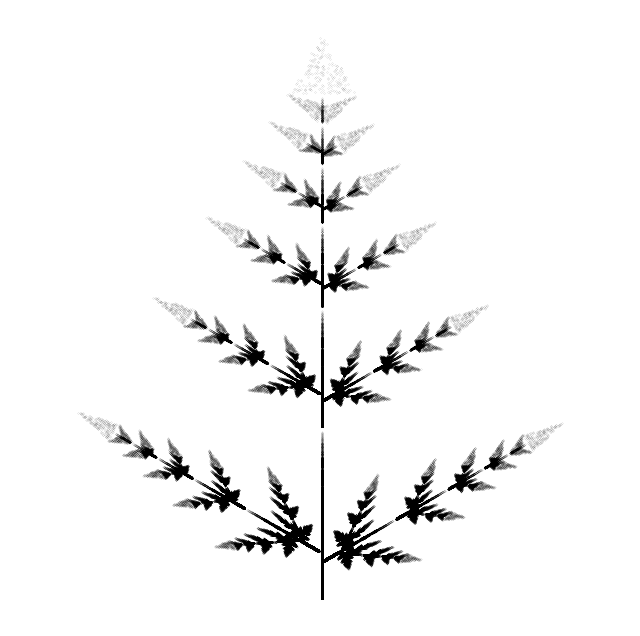

In [6]:
# Ячейка № 6

# визуализация изображения
# фрактала Лист 6-го порядка,
# полученного c помощью ДСИФ,
# с использованием 200 базовых точек
Paporotnic_DSIF(6, 200)